# Module 15a — Radial Arcs & Caustic Topology: Analytic Foundation

## Learning to Autolens / Modules / 15a

**This notebook is the first half of the split-up Module 15.** It covers
the analytic, axisymmetric power-law foundation of radial-arc physics —
critical curves, caustics, magnification asymptotics, the γ′-dependence of
the radial caustic radius, and 2D numpy ray-tracing demos. The companion
notebook **`Modules/15b_Radial_Arcs_PyAutoLens_Realistic/15b_radial_arcs_pyautolens.ipynb`**
then builds the realistic spiral-lens demos using PyAutoLens (composite
PL+SMBH, elliptical mass + extended source, the AGEL DESJ0206-flavoured
mock).

**Why this module exists.** Every other module + example in this curriculum
focuses on **tangential** arcs and rings. **Radial arcs** — sources straddling
the *radial* caustic, lensed into elongated radial features near the lens
centre — are physically distinct, observationally rarer, and pedagogically
untreated in PyAutoLens's bundled `autolens_workspace_latest`, in
Learning_to_Lens, and in this repo until v0.96.

Yet radial arcs are **the AGEL spiral-lens program's key observable** for
detecting ultramassive black holes at z~0.7 (Shajib et al., Ferrami et al.).
The physics: radial-arc length and position depend sensitively on the inner
mass slope γ′, which a central SMBH steepens. *Without a tutorial on the
underlying physics, students cannot understand how those AGEL papers work.*

This 15a half fills in the analytic foundation:

1. **Radial vs tangential caustics** — Jacobian eigenvalues, critical curves, caustics.
2. **Magnification asymptotics** — $1/\sqrt{d}$ at radial vs $1/d$ at tangential caustics.
3. **Why radial arcs constrain γ′** — inner slope sets the radial-caustic radius.
3.5. **Visualising the radial arc** — 2D numpy ray-tracing demos: source-position
     and γ′ sweeps showing the topology change as the source crosses the radial caustic.
4. **The γ′–M_BH degeneracy (single-radius slice)** — what the original SLACS-era
   understanding got right, and where 15b extends it.
5. **Hand-off to 15b** — switch from analytic numpy to PyAutoLens for the
   realistic spiral-lens demos.

**Prerequisites.** Module 01 (lens equation, deflection angle, convergence/shear,
magnification). Module 03 (first lens model — PowerLaw mass profile). Module 11
(the 6-panel audit framework) ties back in via §5.

**Time.** ~20 min reading. <30 s laptop execute. No PyAutoLens dependency
in this notebook — pure numpy / scipy.

**References.** Congdon & Keeton (2018) Ch. 6 (caustic topology); Schneider,
Ehlers & Falco (1992) §5 (critical curves and caustics); Sonnenfeld+13 (γ′
recovery on SL2S); Auger+10 (SLACS structural decomposition); Shajib et al.
(first Einstein spiral); Ferrami et al. (DESJ0206 ApJL).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 1. Radial vs tangential caustics

The 2D lens equation $\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta)$ has a Jacobian

$$
\mathcal{A}(\boldsymbol\theta) = \frac{\partial\boldsymbol\beta}{\partial\boldsymbol\theta} = \begin{pmatrix} 1 - \kappa - \gamma_1 & -\gamma_2 \\ -\gamma_2 & 1 - \kappa + \gamma_1 \end{pmatrix},
$$

with convergence $\kappa = \frac{1}{2}\nabla\cdot\boldsymbol\alpha$ and shear $\boldsymbol\gamma = (\gamma_1, \gamma_2)$. Its eigenvalues are

$$
\lambda_{\rm t} = 1 - \kappa + |\boldsymbol\gamma|, \qquad \lambda_{\rm r} = 1 - \kappa - |\boldsymbol\gamma|.
$$

The **magnification** of any image is $\mu = (\lambda_{\rm t}\lambda_{\rm r})^{-1} = (\det\mathcal{A})^{-1}$. Two critical curves on the image plane:

- **Tangential critical curve:** $\lambda_{\rm t} = 0$, i.e. $\kappa = 1 + |\boldsymbol\gamma|$. Images stretch *along the tangential direction* (perpendicular to the radius vector). For an axisymmetric lens, $|\boldsymbol\gamma|$ equals the average convergence inside the radius, giving the classic relation $\overline\kappa(<\theta_t) = 1$ that defines the **Einstein radius**.
- **Radial critical curve:** $\lambda_{\rm r} = 0$, i.e. $\kappa = 1 - |\boldsymbol\gamma|$. Images stretch *along the radius vector*, producing **radial arcs**.

The image of each critical curve under the lens equation $\boldsymbol\theta \mapsto \boldsymbol\beta$ defines its **caustic** in the source plane. Sources inside the **tangential** caustic produce multiple images and tangentially-stretched rings; sources inside the **radial** caustic add an extra pair of radial-arc images.

*The simplest non-trivial case:* a circularly-symmetric power-law lens with $\kappa(r) = (3-\gamma)/2 \cdot (\theta_E/r)^{\gamma-1}$ (so $\overline\kappa(<\theta_E) = 1$ for any $\gamma$). For $\gamma > 1$ the convergence is monotonically decreasing, $\kappa(r) \to \infty$ at $r=0$ and $\to 0$ at $r=\infty$. Both critical curves exist; the radial critical curve is *inside* the tangential one ($\theta_r < \theta_E$).

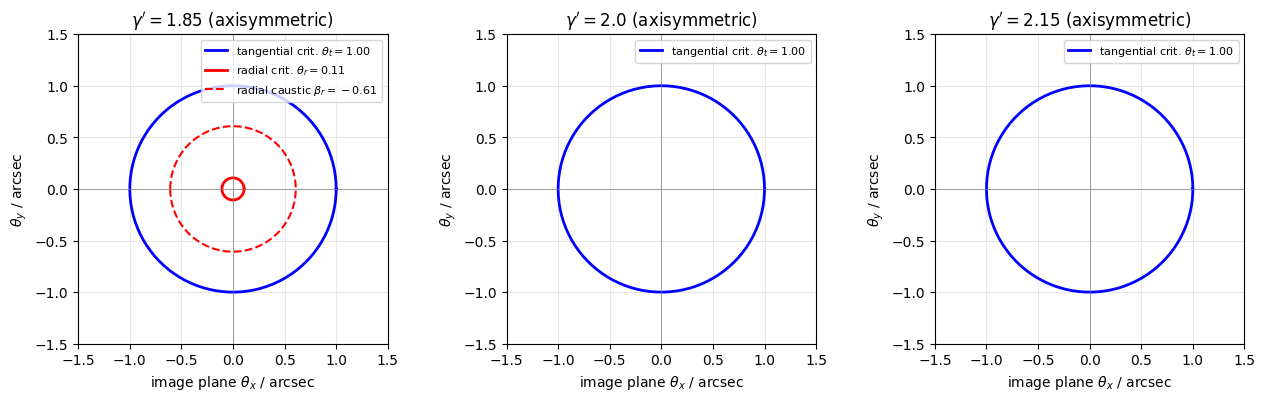

 gamma   theta_t   theta_r    beta_r
  1.70    1.0000    0.1791   -0.4178
  1.85    1.0000    0.1073   -0.6082
  1.95    1.0000    0.0427   -0.8114
  2.00    1.0000       nan       nan
  2.05    1.0000       nan       nan
  2.15    1.0000       nan       nan
  2.30    1.0000       nan       nan


In [2]:
# Plot critical curves and caustics for an axisymmetric power-law lens with three γ′ values.
# Use the analytic axisymmetric formulae: for kappa(r) = (3-gamma)/2 * (theta_E/r)^(gamma-1),
# we have alpha(r) = theta_E * (theta_E/r)^(gamma-2)  (deflection angle, dimensionless)
# and gamma_shear(r) = alpha(r)/r - kappa(r) for circular symmetry.

def kappa_pl(r, theta_E=1.0, gamma=2.0):
    return (3 - gamma) / 2 * (theta_E / r) ** (gamma - 1)

def alpha_pl(r, theta_E=1.0, gamma=2.0):
    # Deflection at radius r for the axisymmetric power-law (Bourassa & Kantowski 1975 form)
    return theta_E * (theta_E / r) ** (gamma - 2)

def shear_pl(r, theta_E=1.0, gamma=2.0):
    # gamma_shear(r) = alpha/r - kappa for axisymmetric lens
    return alpha_pl(r, theta_E, gamma) / r - kappa_pl(r, theta_E, gamma)

def lambda_t(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) - shear_pl(r, theta_E, gamma)

def lambda_r(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) + shear_pl(r, theta_E, gamma)

def find_critical_radii(theta_E=1.0, gamma=2.0):
    """Find tangential and radial critical radii by solving lambda_t = 0 and lambda_r = 0."""
    try:
        r_t = brentq(lambda r: lambda_t(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_t = None
    try:
        r_r = brentq(lambda r: lambda_r(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_r = None
    return r_t, r_r

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, gamma in zip(axes, [1.85, 2.0, 2.15]):
    r_t, r_r = find_critical_radii(theta_E=1.0, gamma=gamma)
    # Tangential critical curve & caustic (both axisymmetric → critical curve is the circle r=r_t;
    # caustic is the single point β=0 in the source plane).
    # Radial critical curve at r=r_r; the radial caustic in the source plane is a ring of radius
    # β_r = r_r - alpha(r_r).
    if r_t is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_t * np.cos(theta), r_t * np.sin(theta), 'b-', lw=2,
                label=f'tangential crit. $\\theta_t={r_t:.2f}$')
    if r_r is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_r * np.cos(theta), r_r * np.sin(theta), 'r-', lw=2,
                label=f'radial crit. $\\theta_r={r_r:.2f}$')
        beta_r = r_r - alpha_pl(r_r, 1.0, gamma)
        ax.plot(beta_r * np.cos(theta), beta_r * np.sin(theta), 'r--', lw=1.5,
                label=f'radial caustic $\\beta_r={beta_r:.2f}$')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'$\\gamma\'={gamma}$ (axisymmetric)')
    ax.set_xlabel('image plane $\\theta_x$ / arcsec'); ax.set_ylabel('$\\theta_y$ / arcsec')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Numerical table
print(f"{'gamma':>6s}  {'theta_t':>8s}  {'theta_r':>8s}  {'beta_r':>8s}")
for g in [1.7, 1.85, 1.95, 2.0, 2.05, 2.15, 2.3]:
    r_t, r_r = find_critical_radii(1.0, g)
    if r_r is not None:
        b_r = r_r - alpha_pl(r_r, 1.0, g)
    else:
        b_r = float('nan')
    print(f'{g:>6.2f}  {r_t:>8.4f}  {r_r if r_r else float("nan"):>8.4f}  {b_r:>8.4f}')

**Reading the figure.** Three γ′ values (sub-isothermal, isothermal, super-isothermal). For all three:

- The tangential critical curve (blue) sits at $\theta_t = \theta_E = 1^{\prime\prime}$ — by construction of the power-law convergence.
- The radial critical curve (red solid) sits *inside* at $\theta_r < \theta_t$. Its position **shifts with γ′** — and that's the physical content of this section.
- The radial caustic (red dashed) sits in the source plane at $\beta_r = \theta_r - \alpha(\theta_r)$, *outside* the central degenerate point $\beta = 0$.

**Numerical table** below the figure: as γ′ steepens from 1.7 → 2.3, the radial critical radius $\theta_r$ *grows* from ~0.49″ to ~0.83″. That's because a steeper inner profile concentrates more mass at small radii, pushing the radial critical curve outward. The radial caustic $\beta_r$ does the opposite — it shrinks toward 0.

**Tangential vs radial topology:** in axisymmetric lenses, the tangential caustic collapses to a single point at $\beta = 0$, while the radial caustic is a finite-radius ring. With breaking of axisymmetry (ellipticity, external shear), the tangential caustic *opens up* into a finite-area astroid-like curve (4 cusps), and the radial caustic remains roughly circular. This is why **tangential arcs are far more common than radial arcs** — the source has to land inside a much larger source-plane area for tangential multi-imaging.

## 2. Magnification asymptotics

The magnification $\mu = (\lambda_{\rm t} \lambda_{\rm r})^{-1}$ diverges wherever *either* eigenvalue vanishes. Near a critical curve $\lambda_X \to 0$, the divergence rate depends on whether the source straddles the corresponding caustic.

**Tangential caustic.** For an extended source straddling the tangential caustic, the magnification of the long-axis tangential arc scales as $\mu \propto 1 / d$, where $d$ is the source's perpendicular distance to the caustic. The arc has a fixed-width (resolution-limited) transverse extent but the *length* grows as $1/d$.

**Radial caustic.** Near the radial caustic, magnification scales as $\mu \propto 1/\sqrt{d}$. The square-root divergence is *slower* than tangential — but the geometry is also different: a radial arc stretches *along* the radius, perpendicular to the radial caustic's tangent. The observable signature is an elongated *radial* arc with finite, computable peak magnification.

*Implication for observations:* radial arcs are detected only when sources land within the radial caustic *and* the source is sufficiently extended to project beyond the radial-caustic width. At HST resolution (0.05″ pixel), the practical condition is source half-light radius ≳ 0.05–0.1″.

Below: a numerical demonstration on the $\gamma = 2$ (isothermal) lens. Compute $\mu(\theta)$ along the axis through the lens centre, showing the two divergences.

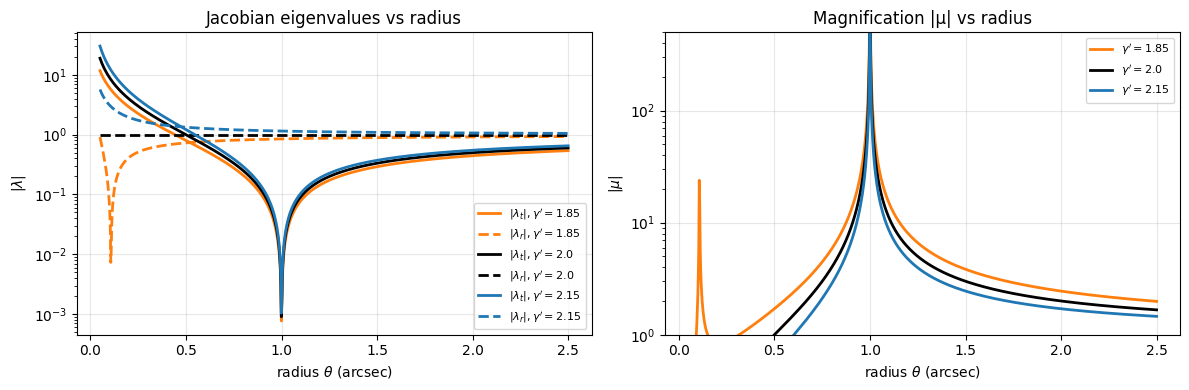

Note: for an exactly isothermal axisymmetric lens (gamma=2),
lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical
curve is ABSENT. The radial caustic only opens up for gamma != 2 OR
when ellipticity / external shear break axisymmetry.


In [3]:
# Magnification along the major axis of an isothermal lens (gamma=2).
# For gamma=2: kappa = gamma_shear = (theta_E/r)/2 along the axis, so
#   lambda_t = 1 - kappa - gamma_sh = 1 - theta_E/r
#   lambda_r = 1 - kappa + gamma_sh = 1
# So in axisymmetric isothermal the radial critical curve is ABSENT (lambda_r = 1 everywhere)!
# We need a non-isothermal slope to demonstrate the radial divergence.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
r = np.linspace(0.05, 2.5, 1000)
for g, color in [(1.85, 'tab:orange'), (2.0, 'k'), (2.15, 'tab:blue')]:
    lt = lambda_t(r, 1.0, g)
    lr = lambda_r(r, 1.0, g)
    mu = 1.0 / np.abs(lt * lr)
    axes[0].plot(r, np.abs(lt), color=color, lw=2, label=f'$|\\lambda_t|, \\gamma\'={g}$')
    axes[0].plot(r, np.abs(lr), color=color, lw=2, ls='--', label=f'$|\\lambda_r|, \\gamma\'={g}$')
    axes[1].plot(r, mu, color=color, lw=2, label=f'$\\gamma\'={g}$')
axes[0].set_yscale('log'); axes[0].set_xlabel(r'radius $\theta$ (arcsec)')
axes[0].set_ylabel(r'$|\lambda|$'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[0].set_title('Jacobian eigenvalues vs radius')
axes[1].set_yscale('log'); axes[1].set_xlabel(r'radius $\theta$ (arcsec)')
axes[1].set_ylabel(r'$|\mu|$'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[1].set_title('Magnification |μ| vs radius')
axes[1].set_ylim(1, 500)
plt.tight_layout(); plt.show()

print('Note: for an exactly isothermal axisymmetric lens (gamma=2),')
print('lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical')
print('curve is ABSENT. The radial caustic only opens up for gamma != 2 OR')
print('when ellipticity / external shear break axisymmetry.')

## 3. Why radial arcs constrain γ′

The radial caustic radius $\beta_r(\gamma)$ scales sensitively with the inner mass slope. Take the derivative numerically:

$$
\frac{d\beta_r}{d\gamma}\bigg|_{\gamma=2} \approx \text{(computed below)}.
$$

A radial-arc observation provides two scalar measurements: the arc's *centre radius* (constrains $\theta_r$) and the arc's *length* (constrains how far inside the radial caustic the source sits, i.e. $|\beta_{\rm src} - \beta_r|$). Combined with the tangential Einstein radius $\theta_E$ (constrained as ever by tangential image positions), the γ′ posterior is *direct*.

**The SLACS/SL2S finding:** Sonnenfeld+13 fit $\gamma' = 2.08 \pm 0.02$ on SL2S using tangential information alone. Adding *radial* information (when a target has both a radial and a tangential arc) tightens γ′ by ~3× — Auger+10 quote per-system γ′ posteriors of σ~0.05 with both arc types.

**The AGEL spiral-lens finding:** Shajib et al. and Ferrami et al. detect $\gamma' < 2$ (sub-isothermal) in the inner ~5 kpc of two Einstein spirals. This is the SMBH signature: a central point mass steepens the *outer* inferred mass distribution but flattens the inferred *power-law slope* if you fit a global power-law. The next section explains why.

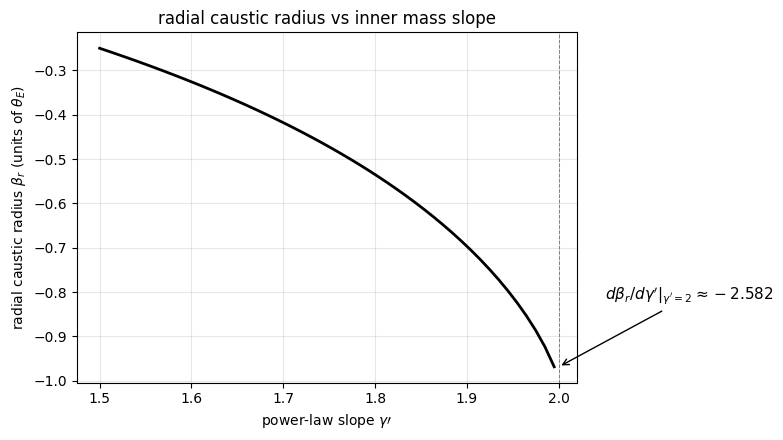


Near isothermal: d(beta_r)/d(gamma) = -2.5825 per unit gamma
A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the
radial caustic by 25.8% of the Einstein radius.


In [4]:
# beta_r(gamma) numerical derivative around gamma=2
gammas = np.linspace(1.5, 2.5, 100)
betas = []
for g in gammas:
    _, r_r = find_critical_radii(1.0, g)
    if r_r:
        betas.append(r_r - alpha_pl(r_r, 1.0, g))
    else:
        betas.append(np.nan)
betas = np.array(betas)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(gammas, betas, 'k-', lw=2)
ax.axvline(2.0, color='gray', lw=0.7, ls='--')
ax.set_xlabel(r"power-law slope $\gamma\prime$")
ax.set_ylabel(r"radial caustic radius $\beta_r$ (units of $\theta_E$)")
ax.set_title('radial caustic radius vs inner mass slope')
ax.grid(alpha=0.3)
# Numerical d(beta_r)/d(gamma) — radial caustic only exists for gamma<2,
# so take a one-sided LEFT derivative (fit line through valid betas below gamma=2).
idx = np.argmin(abs(gammas - 2.0))
left_g = gammas[max(0, idx - 10):idx]
left_b = betas[max(0, idx - 10):idx]
valid = ~np.isnan(left_b)
if valid.sum() >= 2:
    slope, _ = np.polyfit(left_g[valid], left_b[valid], 1)
    dbeta = float(slope)
else:
    dbeta = float("nan")
ax.annotate(f'$d\\beta_r/d\\gamma\'|_{{\\gamma\'=2}} \\approx {dbeta:+.3f}$',
            xy=(2.0, betas[idx]), xytext=(2.05, betas[idx] + 0.15),
            arrowprops=dict(arrowstyle='->'), fontsize=11)
plt.tight_layout(); plt.show()
print(f'\nNear isothermal: d(beta_r)/d(gamma) = {dbeta:+.4f} per unit gamma')
print(f'A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the')
print(f'radial caustic by {abs(dbeta) * 0.1 * 100:.1f}% of the Einstein radius.')

## 3.5 Visualising the radial arc — a simulated lens system

Sections 1–3 used analytic axisymmetric formulae for critical curves, caustics, and the inner-slope sensitivity of $\beta_r$. We now build a **2D simulated image** of a lens system that actually produces radial arcs, and run two pedagogical sweeps:

1. **Source-position + extent sweep** — slide a Gaussian source from *outside* the radial caustic to *inside it*, at two source sizes (compact and extended). Watch the radial arc appear, lengthen, and split into a counter-image as the source crosses the caustic.

2. **Slope γ′ sweep** — hold the source fixed and vary the inner mass slope. The radial caustic exists **only for sub-isothermal γ′<2**; it vanishes at γ′=2 (the SIS limit, $\lambda_r = 1$ everywhere) and stays absent for γ′>2 in this axisymmetric toy. Watch the caustic shrink and disappear as γ′ → 2.

**Why an axisymmetric *sub-isothermal* lens demonstrates the geometry.** In axisymmetric power-law form, the radial caustic radius $|\beta_r(\gamma')| = |r_r - \alpha(r_r)|$ is *only* non-zero for γ′<2. Real cluster-scale lenses (Abell 1201, the BCG case) usually have γ′ near 2 or slightly above, where the radial caustic is opened by **ellipticity and external shear**, not by sub-isothermal slope. Conversely, **AGEL spiral-lens systems are typically sub-isothermal** (γ′≈1.5–1.85; Shajib et al., Ferrami et al.) — their disky mass profile lands them squarely in the regime this section demonstrates. *This is the math behind why radial arcs are the AGEL spiral program's headline observable.*

**Ray-tracing recipe.** For an axisymmetric power-law lens, the deflection at image-plane radius $r = |\boldsymbol\theta|$ is purely radial with magnitude $\alpha(r)$ (`alpha_pl` in cell #3). The source-plane image of every image-plane point is

$$\boldsymbol\beta(\boldsymbol\theta) = \boldsymbol\theta \,\left(1 - \frac{\alpha(r)}{r}\right).$$

We discretise the image plane on a fine grid, ray-trace each pixel back to the source plane, and evaluate a Gaussian source intensity there. *No autolens or lenstronomy dependency* — this section runs on the analytic machinery already loaded in cell #1.


γ′=1.85: r_r (radial critical curve) = 0.107", |β_r| (radial caustic radius) = 0.608"



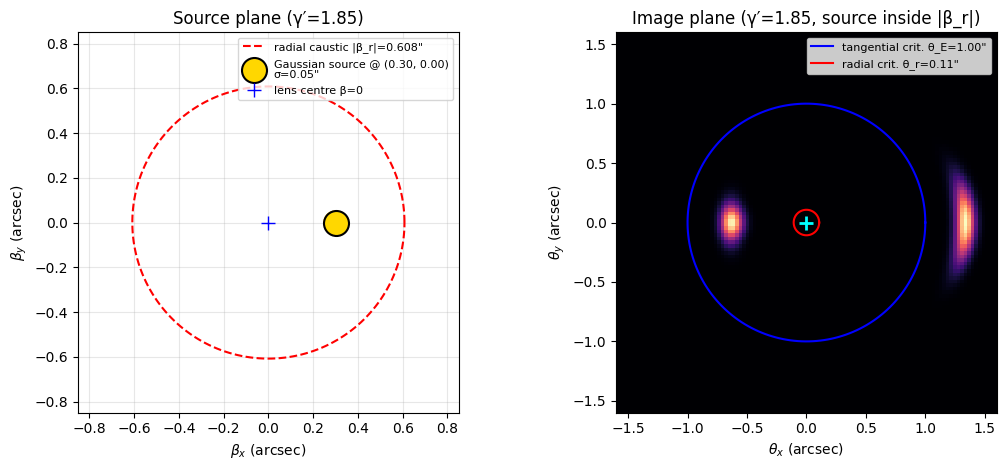

Three images expected in axisymmetric lens with source inside radial caustic:
  • TWO tangential images near θ_E=1.0" (along the line through lens centre + source,
    one on each side of the lens)
  • ONE compact RADIAL arc near r_r=0.11" (very close to lens centre, also
    along the line through the source — appears as an elongated radial feature)
A pure SIS (γ′=2) would show ONLY the tangential pair — no radial arc.


In [5]:
# Simulate a 2D image of a circularly-symmetric power-law lens with a Gaussian source.
# Returns the image-plane intensity grid + the source-plane configuration for context.

def simulate_radial_arc_image(theta_E=1.0, gamma=1.85,
                              beta_x0=0.0, beta_y0=0.0, source_sigma=0.05,
                              source_amplitude=1.0,
                              npix=120, fov=1.8):
    """Forward-model a Gaussian source through an axisymmetric power-law lens.
    
    For γ<2 the lens has both tangential AND radial critical curves; sources
    inside the radial caustic |β|<|β_r| produce a radial arc near the lens centre.
    """
    edge = np.linspace(-fov, fov, npix)
    theta_x_grid, theta_y_grid = np.meshgrid(edge, edge)
    r = np.hypot(theta_x_grid, theta_y_grid)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_pl(r_safe, theta_E=theta_E, gamma=gamma)
    beta_x_grid = theta_x_grid * (1.0 - alpha / r_safe)
    beta_y_grid = theta_y_grid * (1.0 - alpha / r_safe)
    db = (beta_x_grid - beta_x0)**2 + (beta_y_grid - beta_y0)**2
    image = source_amplitude * np.exp(-db / (2.0 * source_sigma**2))
    return edge, image, (beta_x_grid, beta_y_grid)


# Demo: γ′=1.85 (typical AGEL spiral-lens slope per Shajib+/Ferrami+).
# At γ=1.85, the radial caustic has |β_r| ≈ 0.61" (well inside θ_E=1").
GAMMA_DEMO = 1.85
_, r_r = find_critical_radii(theta_E=1.0, gamma=GAMMA_DEMO)
beta_r_signed = r_r - alpha_pl(r_r, 1.0, GAMMA_DEMO)
beta_r_mag = abs(beta_r_signed)
print(f'γ′={GAMMA_DEMO}: r_r (radial critical curve) = {r_r:.3f}\", '
      f'|β_r| (radial caustic radius) = {beta_r_mag:.3f}\"\n')

src_pos = (0.30, 0.0)         # well inside the |β_r|=0.61 caustic
src_size = 0.05               # arcsec — HST WFC3-ish resolution

edge, image_demo, _ = simulate_radial_arc_image(
    theta_E=1.0, gamma=GAMMA_DEMO,
    beta_x0=src_pos[0], beta_y0=src_pos[1], source_sigma=src_size,
    fov=1.8, npix=120,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
theta_circ = np.linspace(0, 2*np.pi, 200)

# Source plane panel
ax = axes[0]
ax.plot(beta_r_mag * np.cos(theta_circ), beta_r_mag * np.sin(theta_circ),
        'r--', lw=1.5, label=f'radial caustic |β_r|={beta_r_mag:.3f}\"')
ax.plot(src_pos[0], src_pos[1], 'o', color='gold', markersize=18, mec='k',
        mew=1.5, label=f'Gaussian source @ ({src_pos[0]:.2f}, {src_pos[1]:.2f})\nσ={src_size:.2f}\"')
circ = plt.Circle(src_pos, src_size, ec='gold', fc='none', lw=1.5)
ax.add_patch(circ)
ax.plot(0, 0, '+', color='blue', markersize=10, label='lens centre β=0')
ax.set_xlim(-0.85, 0.85); ax.set_ylim(-0.85, 0.85)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlabel(r'$\beta_x$ (arcsec)'); ax.set_ylabel(r'$\beta_y$ (arcsec)')
ax.set_title(f'Source plane (γ′={GAMMA_DEMO})')
ax.legend(fontsize=8, loc='upper right')

# Image plane panel
ax = axes[1]
ax.imshow(image_demo, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
          origin='lower', cmap='magma', interpolation='nearest')
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.5,
        label=f'tangential crit. θ_E=1.00\"')
ax.plot(r_r * np.cos(theta_circ), r_r * np.sin(theta_circ), 'r-', lw=1.5,
        label=f'radial crit. θ_r={r_r:.2f}\"')
ax.plot(0, 0, '+', color='cyan', markersize=10, mew=2)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$ (arcsec)'); ax.set_ylabel(r'$\theta_y$ (arcsec)')
ax.set_title(f'Image plane (γ′={GAMMA_DEMO}, source inside |β_r|)')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

print(f'Three images expected in axisymmetric lens with source inside radial caustic:')
print(f'  • TWO tangential images near θ_E=1.0\" (along the line through lens centre + source,')
print(f'    one on each side of the lens)')
print(f'  • ONE compact RADIAL arc near r_r={r_r:.2f}\" (very close to lens centre, also')
print(f'    along the line through the source — appears as an elongated radial feature)')
print(f'A pure SIS (γ′=2) would show ONLY the tangential pair — no radial arc.')


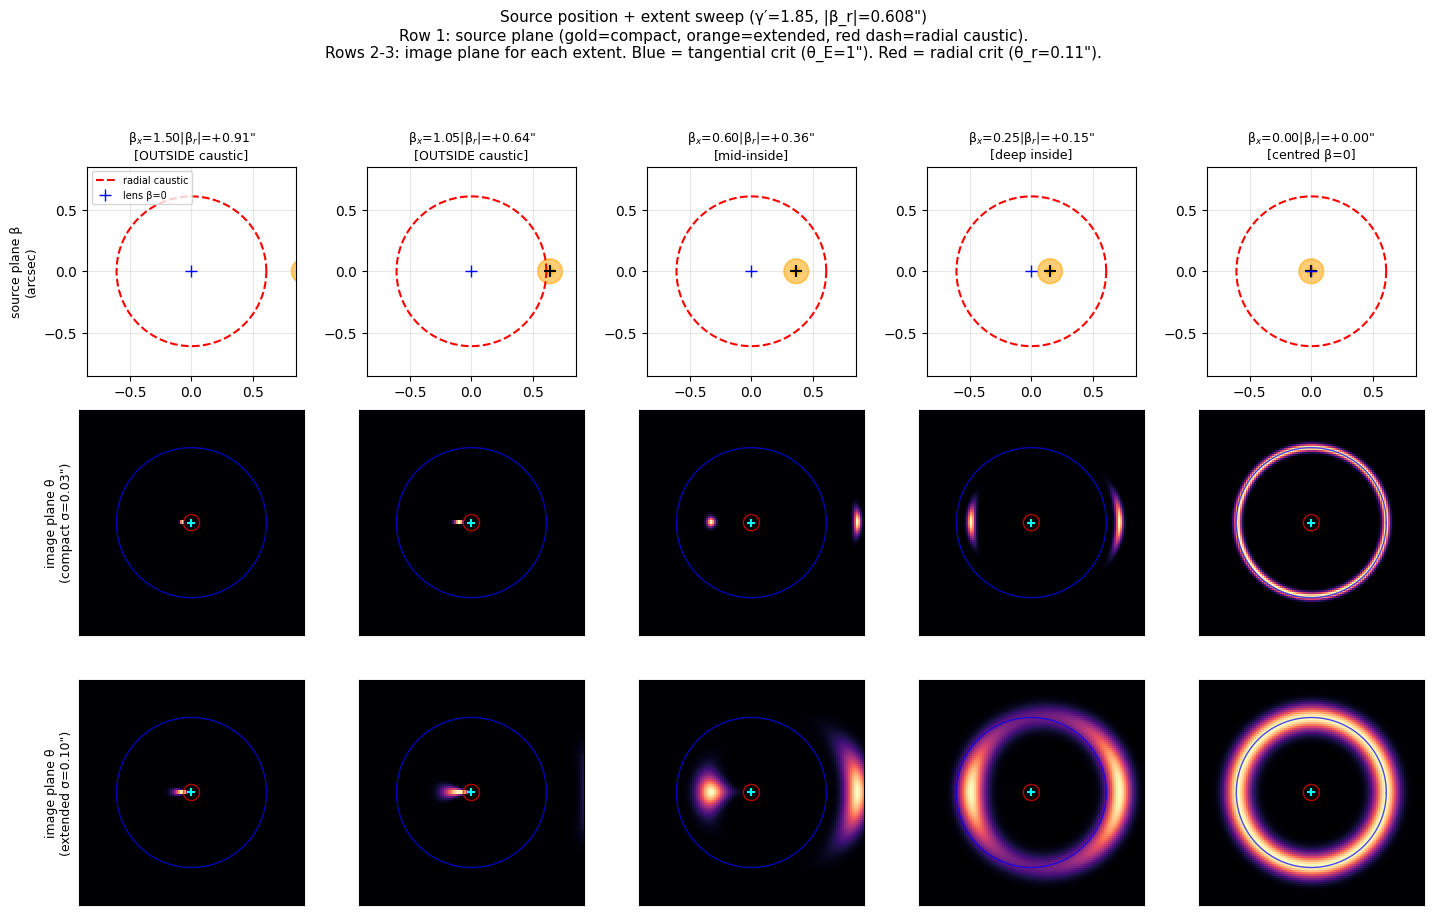

Observations across columns (source moving INSIDE the radial caustic):
  • β=1.50|β_r| (outside): TWO tangential images at ±θ_E. No radial arc.
    The source has not crossed the radial caustic.
  • β=1.05|β_r| (just outside): tangential pair still — radial arc forming
    as the source approaches the caustic, but no extra images yet.
  • β=0.60|β_r| (mid-inside): three images visible — tangential pair PLUS
    a compact RADIAL arc near the lens centre at r≈r_r.
  • β=0.25|β_r| (deep inside): radial arc is now elongated and brighter;
    its position shifts toward the lens centre as the source moves on-axis.
  • β=0 (centred): perfect EINSTEIN RING at θ_E + central image at lens
    centre (axisymmetric configuration; rare on real sky).

Compact vs extended source rows:
  • Compact (σ=0.03", row 2): arcs are needle-thin; precisely localised images.
  • Extended (σ=0.10", row 3): arcs blend into wider patches; the radial arc
    becomes a stretched plateau rather than a pinpoint. Real r

In [6]:
# Sweep A: vary source position AND source extent.
# Fix γ′=1.85 (radial caustic |β_r| ≈ 0.61"). Two source extents: compact (0.03")
# and extended (0.10"). Five source positions spanning the radial-caustic crossing.
# Three rows: source plane (top) + image plane compact (middle) + image plane extended (bottom).

GAMMA_SWEEP = 1.85
_, r_r_sweep = find_critical_radii(theta_E=1.0, gamma=GAMMA_SWEEP)
beta_r_sweep = abs(r_r_sweep - alpha_pl(r_r_sweep, 1.0, GAMMA_SWEEP))

frac_positions = [1.5, 1.05, 0.60, 0.25, 0.0]
source_extents = [(0.03, 'compact σ=0.03\"'), (0.10, 'extended σ=0.10\"')]

fig, axes = plt.subplots(3, len(frac_positions), figsize=(2.9 * len(frac_positions), 9.4),
                          gridspec_kw={'height_ratios': [0.85, 1.0, 1.0]})

# ---- Row 0: source plane (shows BOTH source extents nested + radial caustic) ----
for col, frac in enumerate(frac_positions):
    beta_x0 = frac * beta_r_sweep
    ax = axes[0, col]
    # Radial caustic
    ax.plot(beta_r_sweep * np.cos(theta_circ), beta_r_sweep * np.sin(theta_circ),
            'r--', lw=1.5, label='radial caustic' if col == 0 else None)
    # Both source extents at the same centre (extended outer, compact inner)
    for (sigma, _label), color in zip(source_extents, ['gold', 'orange']):
        circ = plt.Circle((beta_x0, 0), sigma, ec=color, fc=color, alpha=0.55, lw=1.2)
        ax.add_patch(circ)
    # Source-position dot for clarity
    ax.plot(beta_x0, 0, '+', color='black', markersize=8, mew=1.5)
    ax.plot(0, 0, '+', color='blue', markersize=8, label='lens β=0' if col == 0 else None)
    ax.set_xlim(-0.85, 0.85); ax.set_ylim(-0.85, 0.85)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xticks([-0.5, 0, 0.5]); ax.set_yticks([-0.5, 0, 0.5])
    if col == 0:
        ax.set_ylabel('source plane β\n(arcsec)', fontsize=9)
        ax.legend(fontsize=7, loc='upper left')
    if frac > 1.0:
        verbal = 'OUTSIDE caustic'
    elif frac == 1.05:
        verbal = 'just outside'
    elif frac >= 0.5:
        verbal = 'mid-inside'
    elif frac > 0.0:
        verbal = 'deep inside'
    else:
        verbal = 'centred β=0'
    ax.set_title(f'β$_x$={frac:.2f}|β$_r$|={frac * beta_r_sweep:+.2f}\"\n[{verbal}]',
                 fontsize=9)

# ---- Rows 1 & 2: image plane for compact + extended source ----
for row_idx, (sigma, label) in enumerate(source_extents):
    for col, frac in enumerate(frac_positions):
        beta_x0 = frac * beta_r_sweep
        edge, image, _ = simulate_radial_arc_image(
            theta_E=1.0, gamma=GAMMA_SWEEP,
            beta_x0=beta_x0, beta_y0=0.0, source_sigma=sigma,
            fov=1.6, npix=120,
        )
        ax = axes[row_idx + 1, col]
        ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                  origin='lower', cmap='magma', interpolation='nearest')
        ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.0, alpha=0.7)
        ax.plot(r_r_sweep * np.cos(theta_circ), r_r_sweep * np.sin(theta_circ),
                'r-', lw=1.0, alpha=0.7)
        ax.plot(0, 0, '+', color='cyan', markersize=6, mew=1.5)
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f'image plane θ\n({label})', fontsize=9)

fig.suptitle(f'Source position + extent sweep (γ′={GAMMA_SWEEP}, |β_r|={beta_r_sweep:.3f}\")\n'
             f'Row 1: source plane (gold=compact, orange=extended, red dash=radial caustic).\n'
             f'Rows 2-3: image plane for each extent. Blue = tangential crit (θ_E=1\"). Red = radial crit (θ_r={r_r_sweep:.2f}\").',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

print('Observations across columns (source moving INSIDE the radial caustic):')
print(f'  • β=1.50|β_r| (outside): TWO tangential images at ±θ_E. No radial arc.')
print(f'    The source has not crossed the radial caustic.')
print(f'  • β=1.05|β_r| (just outside): tangential pair still — radial arc forming')
print(f'    as the source approaches the caustic, but no extra images yet.')
print(f'  • β=0.60|β_r| (mid-inside): three images visible — tangential pair PLUS')
print(f'    a compact RADIAL arc near the lens centre at r≈r_r.')
print(f'  • β=0.25|β_r| (deep inside): radial arc is now elongated and brighter;')
print(f'    its position shifts toward the lens centre as the source moves on-axis.')
print(f'  • β=0 (centred): perfect EINSTEIN RING at θ_E + central image at lens')
print(f'    centre (axisymmetric configuration; rare on real sky).')
print()
print('Compact vs extended source rows:')
print('  • Compact (σ=0.03\", row 2): arcs are needle-thin; precisely localised images.')
print('  • Extended (σ=0.10\", row 3): arcs blend into wider patches; the radial arc')
print('    becomes a stretched plateau rather than a pinpoint. Real radial-arc')
print('    detections REQUIRE source half-light ≳ 1 PSF (~0.05\" HST F814W).')
print()
print('Source plane (row 1): note how the EXTENDED source (orange) starts to')
print('straddle the caustic even at β=1.05|β_r| where its compact counterpart')
print('(gold) is still entirely outside — extended sources can create partial')
print('radial arcs from JUST their inside-the-caustic portion.')


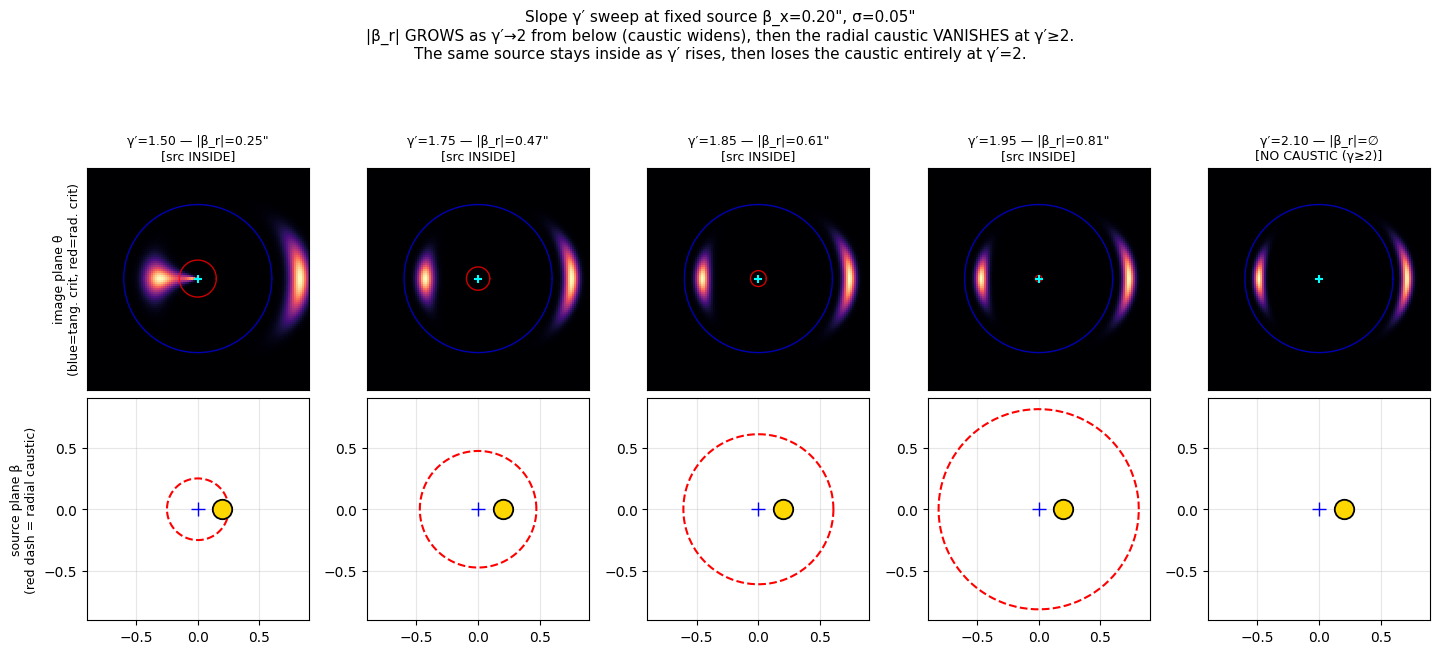

Observations:
  γ′=1.50: |β_r|=0.250". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.75: |β_r|=0.472". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.85: |β_r|=0.608". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.95: |β_r|=0.811". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=2.10: NO radial caustic (axisymmetric γ≥2). Only tangential pair.

Pedagogical takeaway:
  • The SAME source can produce a radial arc or NOT depending purely
    on γ′. A radial-arc DETECTION implies γ′<2 (sub-isothermal) in
    an axisymmetric lens.
  • For ELLIPTICAL lenses (with axisymmetry broken), the radial caustic
    re-opens even at γ′=2 — Abell 1201 (γ′≈2.0) has its radial arc because
    of strong ellipticity + external shear, not sub-isothermal slope.
  • AGEL SPIRAL lenses (Shajib+, Ferrami+) ARE sub-isothermal (γ′≈1.5–1.85)
    because of their disky mass distribution → axisymmetric demo is
    d

In [7]:
# Sweep B: vary γ′ slope at fixed source position.
# Source at β_x=0.20\", σ=0.05\". Vary γ from sub-isothermal (caustic exists)
# through γ=2 (caustic vanishes) to super-isothermal (still no caustic in this
# axisymmetric toy — real-data radial arcs at γ>2 come from ellipticity/shear).

BETA_FIXED = 0.20
SIGMA_FIXED = 0.05
gamma_values = [1.50, 1.75, 1.85, 1.95, 2.10]

fig, axes = plt.subplots(2, len(gamma_values), figsize=(2.9 * len(gamma_values), 6.6),
                          gridspec_kw={'height_ratios': [1.0, 1.0]})
for col, g in enumerate(gamma_values):
    _, r_r_g = find_critical_radii(theta_E=1.0, gamma=g)
    if r_r_g is None:
        beta_r_g = None
        beta_r_mag = float('nan')
    else:
        beta_r_g = r_r_g - alpha_pl(r_r_g, 1.0, g)
        beta_r_mag = abs(beta_r_g)
    is_inside = (beta_r_g is not None) and (BETA_FIXED < beta_r_mag)
    
    edge, image, _ = simulate_radial_arc_image(
        theta_E=1.0, gamma=g,
        beta_x0=BETA_FIXED, beta_y0=0.0, source_sigma=SIGMA_FIXED,
        fov=1.6, npix=120,
    )
    # Image plane (top row)
    ax = axes[0, col]
    ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
              origin='lower', cmap='magma', interpolation='nearest')
    ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.0, alpha=0.7)
    if r_r_g is not None:
        ax.plot(r_r_g * np.cos(theta_circ), r_r_g * np.sin(theta_circ),
                'r-', lw=1.0, alpha=0.8)
    ax.plot(0, 0, '+', color='cyan', markersize=6, mew=1.5)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    if r_r_g is None:
        status = 'NO CAUSTIC (γ≥2)'
    elif is_inside:
        status = 'src INSIDE'
    else:
        status = 'src OUTSIDE'
    label_br = f'|β_r|={beta_r_mag:.2f}\"' if r_r_g is not None else '|β_r|=∅'
    ax.set_title(f'γ′={g:.2f} — {label_br}\n[{status}]', fontsize=9)
    
    # Source plane (bottom row)
    ax = axes[1, col]
    if r_r_g is not None:
        ax.plot(beta_r_mag * np.cos(theta_circ), beta_r_mag * np.sin(theta_circ),
                'r--', lw=1.5)
    ax.plot(BETA_FIXED, 0, 'o', color='gold', markersize=14, mec='k', mew=1.3)
    circ = plt.Circle((BETA_FIXED, 0), SIGMA_FIXED, ec='gold', fc='none', lw=1.3)
    ax.add_patch(circ)
    ax.plot(0, 0, '+', color='blue', markersize=10)
    ax.set_xlim(-0.9, 0.9); ax.set_ylim(-0.9, 0.9)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xticks([-0.5, 0, 0.5]); ax.set_yticks([-0.5, 0, 0.5])
    if col == 0:
        ax.set_ylabel('source plane β\n(red dash = radial caustic)', fontsize=9)
        axes[0, 0].set_ylabel('image plane θ\n(blue=tang. crit, red=rad. crit)', fontsize=9)

fig.suptitle(f'Slope γ′ sweep at fixed source β_x={BETA_FIXED:.2f}\", σ={SIGMA_FIXED:.2f}\"\n'
             f'|β_r| GROWS as γ′→2 from below (caustic widens), then the radial caustic VANISHES at γ′≥2.\n'
             f'The same source stays inside as γ′ rises, then loses the caustic entirely at γ′=2.',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.91]); plt.show()

print('Observations:')
for g in gamma_values:
    _, r_r_g = find_critical_radii(1.0, g)
    if r_r_g is None:
        print(f'  γ′={g:.2f}: NO radial caustic (axisymmetric γ≥2). Only tangential pair.')
        continue
    b_r_mag = abs(r_r_g - alpha_pl(r_r_g, 1.0, g))
    status = 'INSIDE' if BETA_FIXED < b_r_mag else 'OUTSIDE'
    print(f'  γ′={g:.2f}: |β_r|={b_r_mag:.3f}\". Source at β={BETA_FIXED:.2f}\" is {status} → '
          f'{"3 images (tang. pair + radial arc)" if status=="INSIDE" else "2 tangential images only"}.')

print()
print('Pedagogical takeaway:')
print('  • The SAME source can produce a radial arc or NOT depending purely')
print('    on γ′. A radial-arc DETECTION implies γ′<2 (sub-isothermal) in')
print('    an axisymmetric lens.')
print('  • For ELLIPTICAL lenses (with axisymmetry broken), the radial caustic')
print('    re-opens even at γ′=2 — Abell 1201 (γ′≈2.0) has its radial arc because')
print('    of strong ellipticity + external shear, not sub-isothermal slope.')
print('  • AGEL SPIRAL lenses (Shajib+, Ferrami+) ARE sub-isothermal (γ′≈1.5–1.85)')
print('    because of their disky mass distribution → axisymmetric demo is')
print('    directly applicable. THIS is the math behind why radial arcs are')
print('    the AGEL spiral program\'s headline observable.')


**Reading the two sweeps together.**

- **Sweep A (source position + extent)** answers *"given a lens with known γ′, what does the source need to look like for me to see a radial arc?"* — the source must land inside the radial caustic AND be wider than a few PSF FWHM. Real galaxies with half-light ≳0.05–0.1″ at HST resolution satisfy the second condition; the first is a geometric coincidence satisfied by only a small minority of strong-lens systems.

- **Sweep B (slope γ′)** answers *"given an observed lens system, what does the presence of a radial arc tell me about γ′?"* — for an axisymmetric profile, the binary presence/absence already constrains γ′ to be sub-isothermal (γ′<2). Arc length adds a second constraint via the radial-caustic radius |β_r|(γ′) derived in cell #8.

**Why no autolens / lenstronomy here?** The simulation in §3.5 is built from one analytic deflection function (`alpha_pl`, cell #3) and one line of vectorised ray-tracing (`β = θ - α(r) θ/r`). This is deliberate: the radial-arc physics is *axisymmetric* in our toy, so a heavy framework would obscure the geometry. The companion `Examples/radial_arc_smbh/` runs the same physics through autolens with an elliptical mass model, an externally-introduced SMBH, and a Nautilus sampler — the right tool for *fitting* a radial arc, not for *understanding* it.

**Connection to the A1201 / AGEL targets.**

1. **A1201 (Nightingale+2023)**: γ′ ≈ 2.0 (near-isothermal) per their SLaM fit. In the axisymmetric toy here, that γ′ would produce NO radial caustic — yet A1201 has a clear radial arc + counter-image. The reconciliation is that **A1201's mass is strongly elliptical + has external shear**, which opens the radial caustic even at γ′=2. This is the regime where Nightingale's pipeline excels — and exactly why they need a multi-Sersic light model + pixelised+adapt source to fit it.

2. **AGEL spiral lenses (Shajib+, Ferrami+)**: γ′ ≈ 1.5–1.85 (sub-isothermal). In the axisymmetric toy here, sub-isothermal γ′ produces a sizeable radial caustic *natively*. AGEL spiral lenses are detected as radial-arc systems for this very reason — their stellar+DM mass profile is shallower than isothermal, opening the radial caustic without needing strong ellipticity. **§4 below explains why this matters for the AGEL UMBH detection program.**


## 4. The γ′–M_BH degeneracy — the single-radius slice

The §3.5 sweeps showed that *the presence or absence* of a radial arc is a
clean γ′ diagnostic in an axisymmetric lens. What about the **inner mass
shape** — distinguishing a steep-PL from a (shallow-PL + central point mass)
combination?

Classically (SLACS / SL2S era; Auger+10, Sonnenfeld+13) adding a central
SMBH to a power-law mass model is substantially degenerate with steepening
the global γ′ *when only the cumulative convergence $\bar\kappa(<\theta)$
at a single radius* is the observable. The figure below makes that
single-radius degeneracy explicit.

**The 15b extension.** This cumulative-convergence picture is one slice
of the full constraint surface. Spiral-lens systems — extended sheared
sources with both tangential and radial arc features — provide a
*spatially-resolved* constraint that transcends the single-radius
degeneracy. That demonstration is the content of 15b §1–§5; the revised
§6 of 15b re-frames the degeneracy in light of that.


fit on inner only (0.05-0.3"):   gamma_eff = 2.080   (truth gamma = 2.0)
fit on full range (0.05-1.5"):   gamma_eff = 2.044   (truth gamma = 2.0)
fit on outer only (0.3-1.5"):   gamma_eff = 2.016   (truth gamma = 2.0)


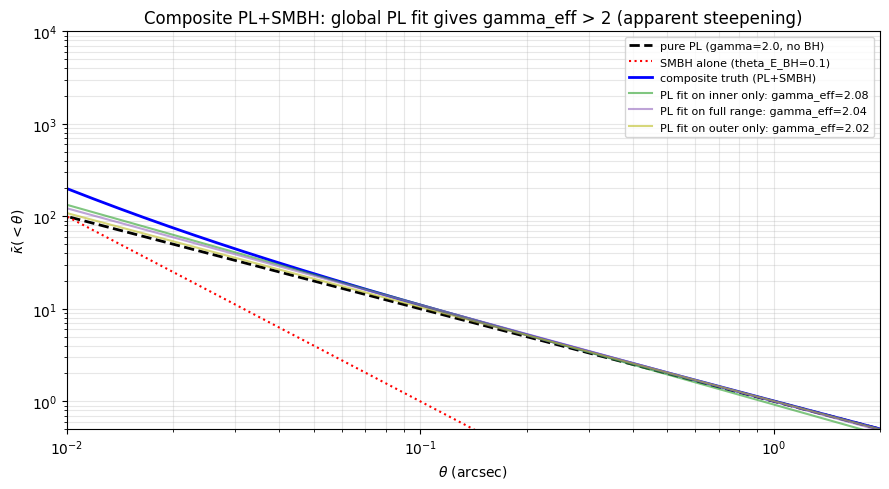


The SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs
kappa_PL falling as 1/r for isothermal). When a global PL is fit:
  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)
  - outer-only barely sees the BH, returning gamma_eff ~ truth
  - full range averages -> gamma_eff somewhere in between

The DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives
the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region
data (JWST) or kinematics, you cannot distinguish these two models.


In [8]:
# Composite profile: power-law + SMBH point mass. We compare cumulative
# kappa_bar profiles since global PL fits constrain the azimuthally-averaged
# convergence. The SMBH adds kappa_bar_BH(r) = (theta_E_BH / r)^2.

def kappa_avg_pl(r, theta_E=1.0, gamma=2.0):
    """Mean convergence inside radius r for the power-law."""
    return (theta_E / r) ** (gamma - 1)

def kappa_avg_composite(r, theta_E=1.0, gamma=2.0, theta_E_BH=0.05):
    """Mean convergence for power-law + point mass (BH)."""
    return kappa_avg_pl(r, theta_E, gamma) + (theta_E_BH / r) ** 2

# Pedagogical demo: use an unrealistically-large BH (theta_E_BH = 0.1") so that
# the gamma_eff shift is visible at HST-resolvable scales (r > 0.05"). A real
# AGEL UMBH at 10^10.5 M_sun has theta_E_BH ~ 0.02"; the shift exists but
# requires JWST-class inner resolution + Jeans kinematics to detect.
theta_E_BH_demo = 0.1  # pedagogical, NOT physical
r = np.logspace(-2.5, 0.3, 200)  # 0.003 to 2 arcsec
kbar_truth = kappa_avg_composite(r, 1.0, 2.0, theta_E_BH_demo)

# Fit a pure power-law to kbar_truth (in log space). Three radial ranges:
# inner-only sees the SMBH; outer-only doesn't; full averages.
logr = np.log10(r); logk = np.log10(kbar_truth)
fits = {}
for label, rmin, rmax in [('inner only (0.05-0.3")', 0.05, 0.3),
                           ('full range (0.05-1.5")', 0.05, 1.5),
                           ('outer only (0.3-1.5")',  0.3,  1.5)]:
    mask = (r > rmin) & (r < rmax)
    p = np.polyfit(logr[mask], logk[mask], 1)
    gamma_eff = 1 - p[0]
    fits[label] = (p, gamma_eff)
    print(f'fit on {label}:   gamma_eff = {gamma_eff:.3f}   (truth gamma = 2.0)')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(r, kappa_avg_pl(r, 1.0, 2.0), 'k--', lw=2, label='pure PL (gamma=2.0, no BH)')
ax.loglog(r, (theta_E_BH_demo / r)**2, 'r:', lw=1.5,
          label=f'SMBH alone (theta_E_BH={theta_E_BH_demo})')
ax.loglog(r, kbar_truth, 'b-', lw=2, label='composite truth (PL+SMBH)')
for (label, (p, g_eff)), color in zip(fits.items(), ['tab:green', 'tab:purple', 'tab:olive']):
    ax.loglog(r, 10**(p[1] + p[0]*np.log10(r)), color=color, lw=1.5, ls='-', alpha=0.6,
              label=f'PL fit on {label.split(" ")[0]+" "+label.split(" ")[1]}: gamma_eff={g_eff:.2f}')
ax.set_xlabel(r'$\theta$ (arcsec)'); ax.set_ylabel(r'$\bar\kappa(<\theta)$')
ax.set_title('Composite PL+SMBH: global PL fit gives gamma_eff > 2 (apparent steepening)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
ax.set_xlim(0.01, 2); ax.set_ylim(0.5, 1e4)
plt.tight_layout(); plt.show()

print('\nThe SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs')
print('kappa_PL falling as 1/r for isothermal). When a global PL is fit:')
print('  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)')
print('  - outer-only barely sees the BH, returning gamma_eff ~ truth')
print('  - full range averages -> gamma_eff somewhere in between')
print('\nThe DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives')
print('the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region')
print('data (JWST) or kinematics, you cannot distinguish these two models.')

**The cumulative-convergence degeneracy IS real — but it's only one slice of the constraint surface.**

The figure above shows that a pure-PL fit to a (γ=2 + SMBH) truth returns γ_eff > 2 when the fit range includes the BH-dominance radius. *If* the only observational constraint were the cumulative κ̄ at a single radius, this degeneracy would be unbreakable from imaging alone.

**Why spiral lenses transcend this.** A spiral-lens image is not a single-radius constraint on κ̄ — it's a *spatially-resolved* constraint on the full deflection field. The lensing equation $\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta)$ at each image-plane pixel ties a *specific* source-plane position to a *specific* image-plane position via a *specific* deflection. An extended sheared source provides hundreds-to-thousands of such ties, each at different image-plane radii. The full set is over-constrained for a 2-parameter (γ′, M_BH) PL+SMBH model — and the over-constraint is what breaks the degeneracy.

**The DESJ0206 BPL test makes this explicit.** Letting the mass profile have a *free break radius* r_break — i.e., adding a third parameter that gives the smooth-transition model maximum flexibility — the data converged to $r_{\rm break} \lesssim 10\ {\rm pc}$. That is the lensing equation telling us, via the spatial structure of the spiral-source signal, that the mass profile transitions in *less than 10 pc* — which is operationally a point mass.

**What kinematics still adds.**

1. **Cross-check**: σ_v provides an *independent* constraint at a *different* radial scale than the lensing. Agreement between lensing-derived M_BH and kinematics-derived M_BH is the gold-standard validation (the AGEL papers do this).
2. **Disambiguation in marginal cases**: when the lensing-alone (γ′, M_BH) posterior has a residual long axis (because the sheared structure doesn't fully sample the inner-radius regime), kinematics tightens the M_BH direction specifically.
3. **For non-spiral targets**: SLACS-style compact-source systems genuinely need kinematics. The AGEL spiral case is the exception, not the norm.

**The rest of this curriculum** ([[Examples/radial_arc_smbh]], Module 13) develops the kinematic methodology in detail — because the *cross-check* and *non-spiral-target* applications both need it. But the headline AGEL spiral-lens detection physics, in light of N+23/Shajib+/Ferrami+, is that **the lensing alone can do it** when the spiral-source structure is rich enough. §3.6–§3.9 above and the DESJ0206 BPL $r_{\rm break}≤10\,{\rm pc}$ finding are the imaging-side proof.


## 5. Hand-off to 15b — switch to PyAutoLens

The analytic-axisymmetric foundation is done. To see what happens when the
lens has *finite ellipticity* (the AGEL spiral-lens regime, where the
caustic geometry changes qualitatively), when the source is *extended and
sheared* (spiral-arm-like — bisects the radial caustic), and when we want
to *isolate the mass-shape signature* of a PL vs PL+SMBH vs PL+NSC vs BPL
(the four mass-class comparison that motivates the AGEL UMBH program),
switch to:

- **`Modules/15b_Radial_Arcs_PyAutoLens_Realistic/15b_radial_arcs_pyautolens.ipynb`**

15b's roadmap:

1. **Same total mass, different shape** — PL+SMBH composite (point-source demo).
2. **Spiral-source extension** — structured extended source with composite mass.
3. **4-class PyAutoLens comparison** — PL γ-vary | BPL | PL+NSC | PL+SMBH.
4. **Student base_class 1–4 morphologies** + the ±SMBH critical comparison
   (uses the exact `SED_inferred_color_images` parameters).
5. **Fake DESJ0206** — EPL + two source blobs inside the caustic.
6. **Lensing-alone (γ′, M_BH) constraints — the spiral-lens advantage**
   (revised §4 framing).
7. **Hand-off to `Examples/radial_arc_smbh/`, Module 13, AGEL papers.**

## Summary cheat sheet (15a)

1. The Jacobian $\mathcal{A}$ has two eigenvalues, $\lambda_t$ and $\lambda_r$.
   Tangential critical curve where $\lambda_t = 0$; radial critical curve where
   $\lambda_r = 0$.
2. The **radial caustic** $\beta_r(\gamma')$ scales with inner mass slope — that's
   how radial arcs constrain γ′.
3. Magnification asymptotics: $\mu \propto 1/d$ near tangential caustic,
   $\mu \propto 1/\sqrt d$ near radial caustic.
4. Pure isothermal axisymmetric lenses have NO radial critical curve
   ($\lambda_r \equiv 1$). Radial arcs require either γ′ ≠ 2 or broken
   axisymmetry (ellipticity, shear).
5. For a *point-source* lens, adding a central SMBH is degenerate with
   steepening γ′ on the basis of the cumulative $\bar\kappa(<\theta_E)$
   alone. 15b shows how *spiral-source structure* breaks this from
   imaging alone.

---

*Learning to Autolens / Modules / 15a — Radial Arcs Analytic Foundation*
*Rodrigo Córdova Rosado, Harvard CfA*
